In [108]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/main_experiment_25'

results_df = pd.read_csv(os.path.join(dir, 'results.csv')).drop(columns=['Unnamed: 0'])

results_means_df = pd.read_csv(os.path.join(dir, 'results_means.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

print(f"""
RUNTIMES

MEANS = {results_means_df['error'].mean()}
BASE = {results_df['error'].mean()}
""")

results_df['pci_beam_config'] = results_df['pci_beam_config'].astype(int)

results_df.groupby('pci_beam_config')[['error', 'runtime']].mean()

results_df


RUNTIMES

MEANS = 15.520576402983934
BASE = 15.521502823830737



,error,complexity,runtime,run,pci_beam_config
0,9.030282,21042.0,0.743644,0.0,0
1,98.935655,21042.0,0.743644,0.0,0
2,20.608276,21042.0,0.743644,0.0,0
3,37.639838,21042.0,0.743644,0.0,0
4,19.369266,21042.0,0.743644,0.0,0
...,...,...,...,...,...
253580,2.350895,176866.0,18.183053,19.0,4
253581,0.119510,176866.0,18.183053,19.0,4
253582,6.474520,176866.0,18.183053,19.0,4
253583,15.551909,176866.0,18.183053,19.0,4


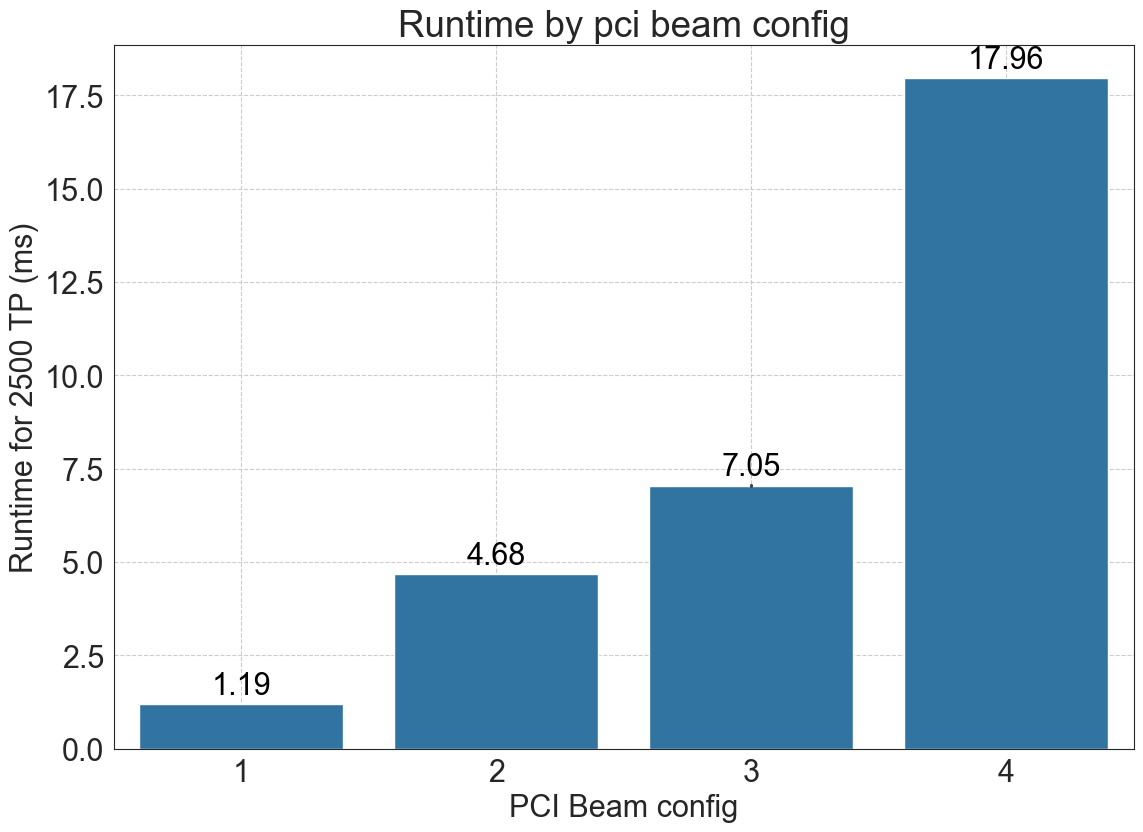

In [117]:
import seaborn as sns


def plot(df: pd.DataFrame, x: str, y: str, x_label: str, y_label: str, title: str):
    plt.rcParams.update({"font.size": 22})

    plt.figure(figsize=(12, 8))

    sns.set_style("white")
    ax = sns.barplot(y=y, x=x, data=df)

    # Add labels on top of bars
    for p in ax.patches:
        # p.get_x() = left edge of bar, p.get_width() = width, p.get_height() = height
        ax.annotate(
            f'{p.get_height():,.2f}',  # Format with 2 decimals, adjust as needed
            (p.get_x() + p.get_width() / 2, p.get_height()),  # Position at bar top center
            ha='center', va='bottom',  # Centered horizontally, just above bar
            color='black', xytext=(0, 3), textcoords='offset points'
        )

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(linestyle='--')
    plt.subplots_adjust(left=0.10, right=0.95, bottom=0.12, top=1)

    plt.show()


plot(results_df[results_df['pci_beam_config'] > 0], x='pci_beam_config', y='runtime', x_label='PCI Beam config',
     y_label='Runtime for 2500 TP (ms)',
     title='Runtime by pci beam config')


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_21373/2019781489.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


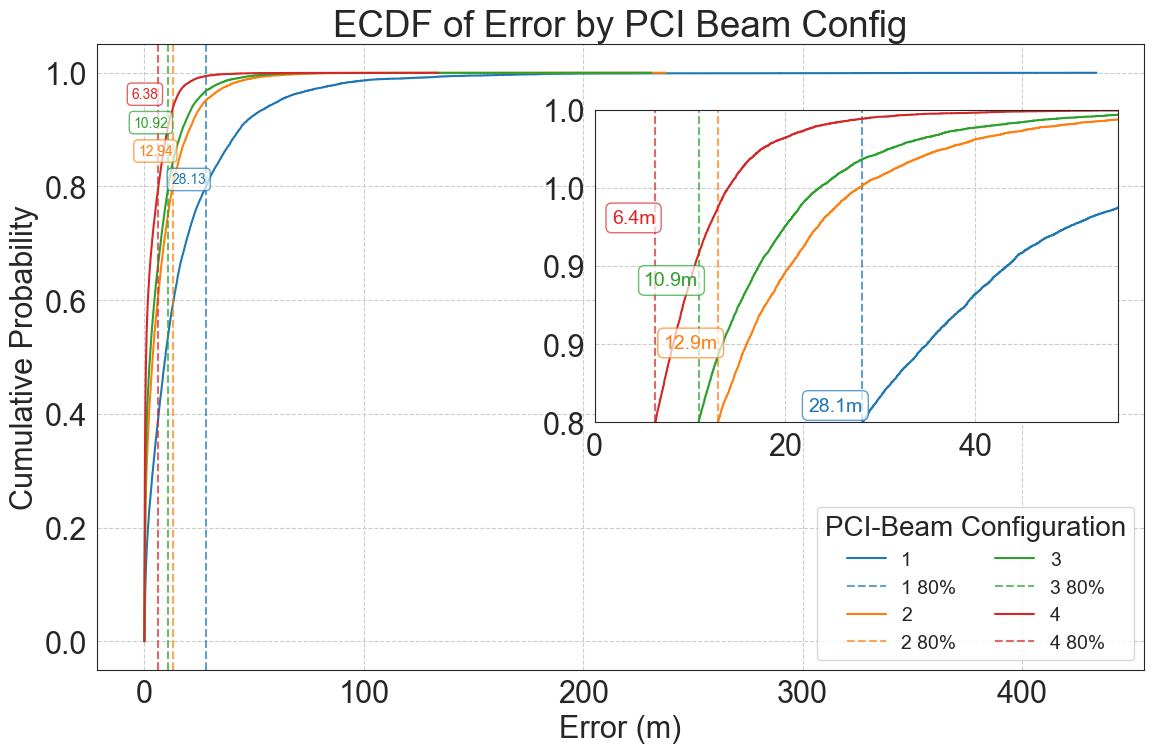

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

plt.rcParams.update({"font.size": 22})


def plot_ecdf(df: pd.DataFrame, x: str, hue: str, x_label: str, y_label: str, title: str):
    fig, ax = plt.subplots(figsize=(12, 8))

    unique_configs = df[hue].unique()
    colors = plt.cm.tab10.colors  # for consistent coloring

    for idx, config in enumerate(unique_configs):
        data = df[df[hue] == config][x]
        x_values = np.sort(data)
        y_values = np.arange(1, len(x_values) + 1) / len(x_values)
        color = colors[idx % len(colors)]
        ax.step(x_values, y_values, where='post', label=f'{config}', color=color)

        p80 = np.percentile(data, 80)
        ax.axvline(p80, color=color, linestyle='--', alpha=0.7)
        ax.text(p80, 0.8 + 0.05 * idx, f'{p80:.2f}', color=color, va='bottom', ha='right', fontsize=10, rotation=0,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor=color, boxstyle='round,pad=0.3'))

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(linestyle='--')
    ax.legend(title=hue)

    # Create inset for zoomed-in section
    ax_inset = inset_axes(ax, width="50%", height="50%", loc='upper right',
                          bbox_to_anchor=(-0.01, -0.08, 1, 1),  # 0.07 = 7% horizontal padding
                          bbox_transform=ax.transAxes,
                          )

    for idx, config in enumerate(unique_configs):
        data = df[df[hue] == config][x]
        x_values = np.sort(data)
        y_values = np.arange(1, len(x_values) + 1) / len(x_values)
        color = colors[idx % len(colors)]
        ax_inset.step(x_values, y_values, where='post', label=f'{config}', color=color)

        # Inset: vertical lines and labels
        p80 = np.percentile(data, 80)
        ax_inset.axvline(p80, color=color, linestyle='--', alpha=0.7)
        ax_inset.text(p80, 0.805 + 0.04 * idx, f'{p80:.1f}m', color=color, va='bottom', ha='right', fontsize=14,
                      rotation=0, bbox=dict(facecolor='white', alpha=0.7, edgecolor=color, boxstyle='round,pad=0.3')
                      )

    # Set limits for the inset to focus on the top 90th percentile
    ax_inset.set_xlim(0, 55)
    ax_inset.set_ylim(0.8, 1.0)
    ax_inset.grid(linestyle='--')

    #ax.set_xlim(-10,200)

    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax_inset.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    # Prepare legend handles
    handles, labels = ax.get_legend_handles_labels()
    custom_handles = []
    custom_labels = []
    for idx, config in enumerate(unique_configs):
        color = colors[idx % len(colors)]
        # ECDF line handle (already in handles)
        # 80th percentile line handle
        p80_handle = Line2D([0], [0], color=color, linestyle='--', alpha=0.7)
        custom_handles.append(handles[idx])  # ECDF
        custom_labels.append(f'{config}')
        custom_handles.append(p80_handle)  # 80th percentile
        custom_labels.append(f"{config} 80%")
    ax.legend(custom_handles, custom_labels, fontsize=14, title_fontsize=20, loc='lower right', ncol=2,
              title="PCI-Beam Configuration")
    plt.tight_layout()
    plt.show()


# Plotting ECDFs for different PCI beam configurations

plotting_df = results_df[results_df['pci_beam_config'] > 0]
plot_ecdf(plotting_df, x='error', hue='pci_beam_config', x_label='Error (m)', y_label='Cumulative Probability',
          title='ECDF of Error by PCI Beam Config')


In [127]:
pci_beam_configs = [
    [1, 1],  # Baseline
    [2, 2],  # Lightweight
    [15, 2],  # Balanced
    [None, 2],  # Accurate
    [None, None],  # Maximized
]

table_data = []
for config, data in results_df.groupby('pci_beam_config'):
    config = int(config)
    n_pcis, n_beams = pci_beam_configs[config][0], pci_beam_configs[config][1]
    errors = data['error']
    n80 = np.percentile(errors, 80)
    mean_err = np.mean(errors)
    std_err = np.std(errors)
    runtime = np.mean(data['runtime'])
    table_data.append([config, n_pcis, n_beams, n80, mean_err, std_err, runtime])

table_df = pd.DataFrame(table_data,
                        columns=['config', 'n_pcis', 'n_beams', '80% error', 'mean error', 'std error', 'runtime'])

table_df = table_df.round(2)
table_df['n_beams'] = table_df['n_beams'].apply(lambda x: 'All' if np.isnan(x) else f'{int(x)}')
table_df['n_pcis'] = table_df['n_pcis'].apply(lambda x: 'All' if np.isnan(x) else f'{int(x)}')

table_df[table_df['config'] > 0]

,config,n_pcis,n_beams,80% error,mean error,std error,runtime
1,1,2,2,28.13,17.60,25.09,1.19
2,2,15,2,12.94,7.73,10.59,4.68
3,3,All,2,10.92,6.31,9.14,7.05
4,4,All,All,6.38,3.44,5.78,17.96
